In [45]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")
# import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### **Used car assessor: What drives the price of a car?**  
This notebook will determine which features make some cars more expensive, or others less expensive.

# **Business understanding**

Using the vehicles dataset, I will do some analysis to determine which factors drive the price of a used car. I will perform exploratory data analysis and build Machine Learning models to find the key drivers of a used car's price.

# **Data Understanding**

In this section I will explore the vehicles dataset to understand the fpllowing aspects:

* **Data types:** how many variables are there? What data types? Are there only numeric variables or also categorigal ones?  
* **data quality:** How many missing values are there? How many variables have a single value for all rows?
* **Correlations:** Which variables are correlated with each other or with price?
* **Data distributions:** What is the distribution of the variables? Which of them are skewed?
* **Outliers:** Are there aany outliers in the dataset? If so, how do we handle them?





In [46]:
df = pd.read_csv('data/vehicles.zip', compression='zip')

In [47]:
df.shape

(426880, 18)

In [48]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [50]:
# show missing variables
df.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [51]:
df = df.dropna()
df.shape



(34868, 18)

In [52]:
df.isna().sum()

id              0
region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
VIN             0
drive           0
size            0
type            0
paint_color     0
state           0
dtype: int64

In [53]:
# show variables that have the same value for all rows
df.nunique()


id              34868
region            392
price            3136
year               89
manufacturer       41
model            5139
condition           6
cylinders           8
fuel                5
odometer        16689
title_status        6
transmission        3
VIN             21938
drive               3
size                4
type               13
paint_color        12
state              51
dtype: int64

In [54]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


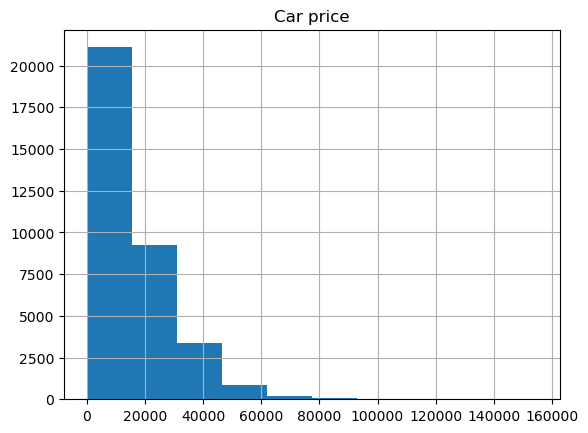

In [55]:
df['price'].hist()
plt.title('Car price')
plt.show()

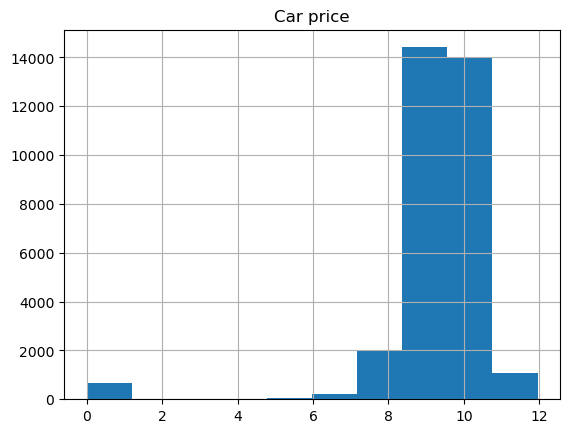

In [56]:
# plot the histogram of the log of price
# plot the histogram of the log of price
# Filter out rows where price is 0 before calculating the log
df_filtered = df[df['price'] > 0].copy()
df_filtered['log_price'] = np.log(df_filtered['price'])
df_filtered['log_price'].hist()
plt.title('Car price')
plt.show()

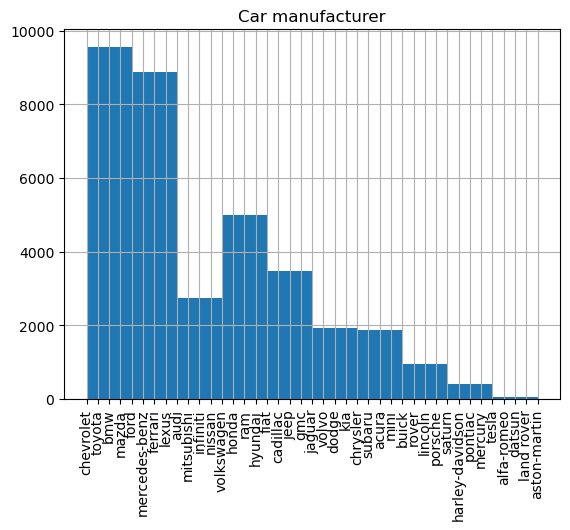

In [57]:
df['manufacturer'].hist()
plt.title('Car manufacturer')
plt.xticks(rotation=90)
plt.show()

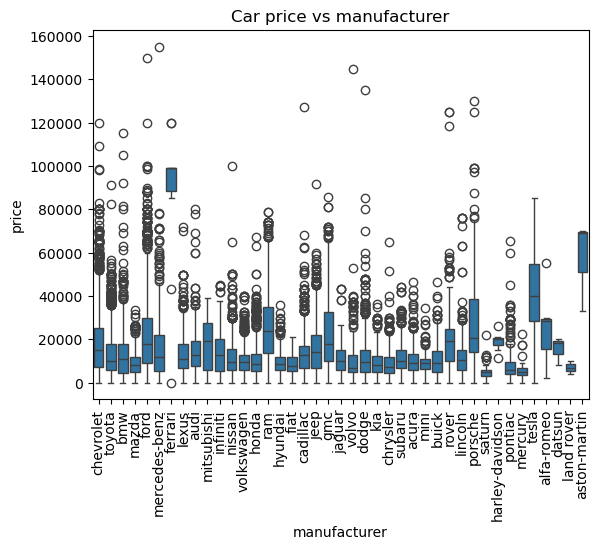

In [58]:
# Price vs manufacturer
sns.boxplot(x='manufacturer', y='price', data=df)
plt.title('Car price vs manufacturer')
plt.xticks(rotation=90)
plt.show()

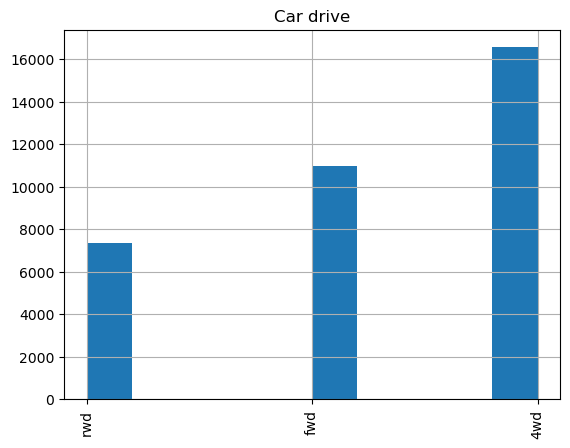

In [59]:
df['drive'].hist()
plt.title('Car drive')
plt.xticks(rotation=90)
plt.show()

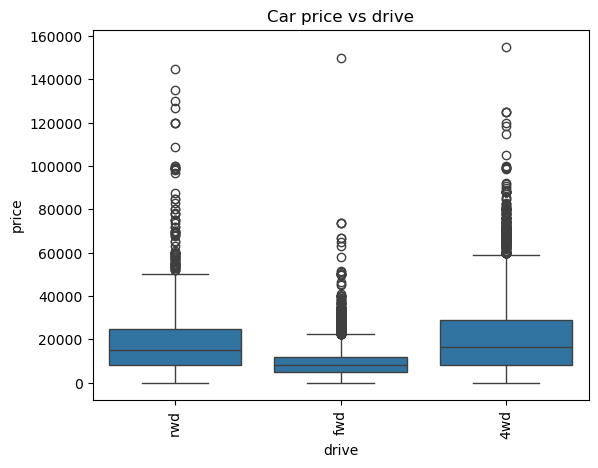

In [60]:
# Car price vs drive
sns.boxplot(x='drive', y='price', data=df)
plt.title('Car price vs drive')
plt.xticks(rotation=90)
plt.show()




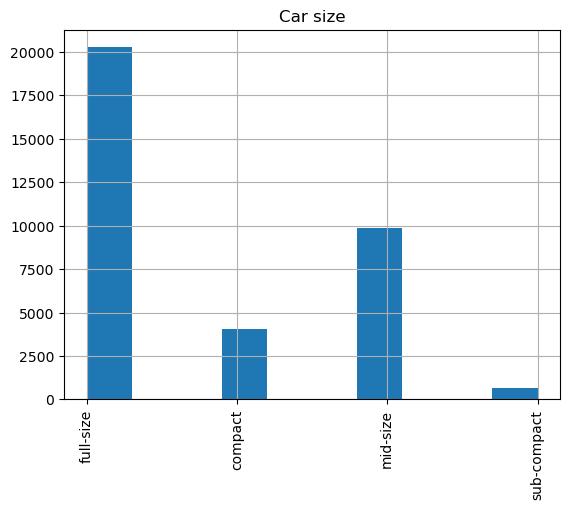

In [61]:
df['size'].hist()
plt.title('Car size')
plt.xticks(rotation=90)
plt.show()

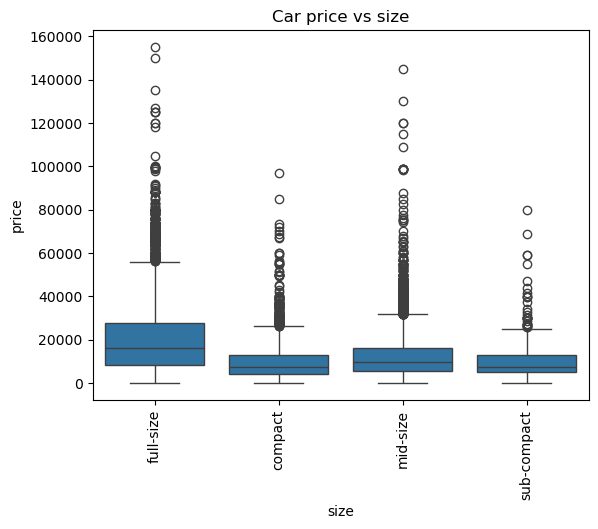

In [62]:
# Plot price vs size
sns.boxplot(x='size', y='price', data=df)
plt.title('Car price vs size')
plt.xticks(rotation=90)
plt.show()

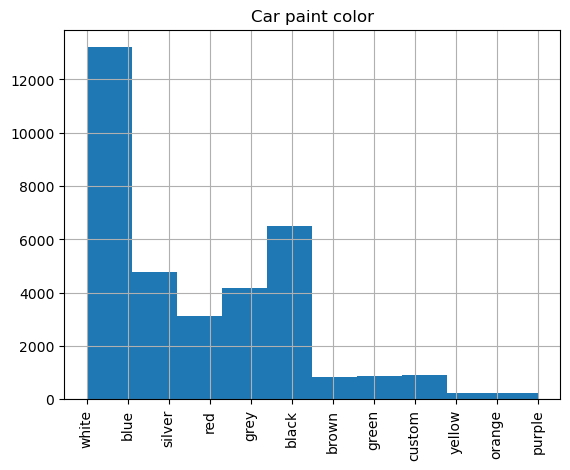

In [63]:
df['paint_color'].hist()
plt.title('Car paint color')
plt.xticks(rotation=90)
plt.show()
#

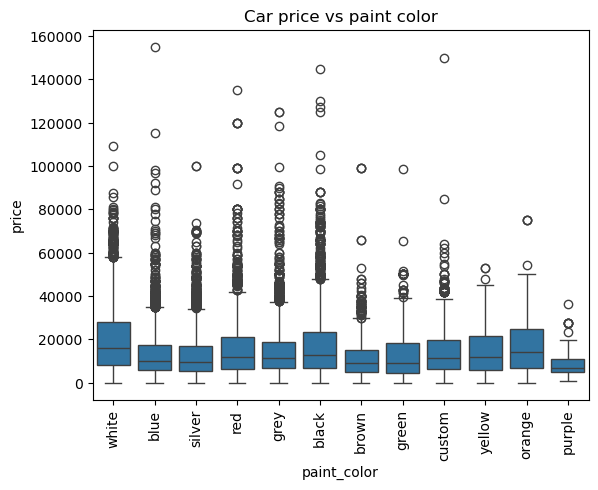

In [64]:
# Price vs Paint color
sns.boxplot(x='paint_color', y='price', data=df)
plt.title('Car price vs paint color')
plt.xticks(rotation=90)
plt.show()

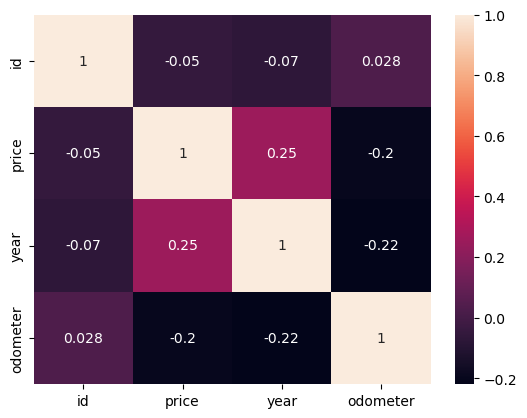

In [65]:
# Check correlations
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

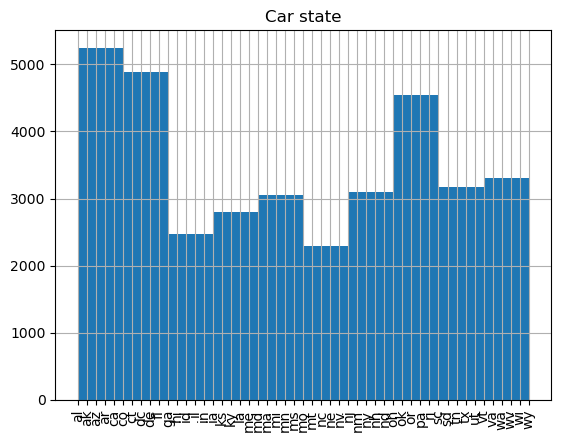

In [66]:
df['state'].hist()
plt.title('Car state')
plt.xticks(rotation=90)
plt.show()


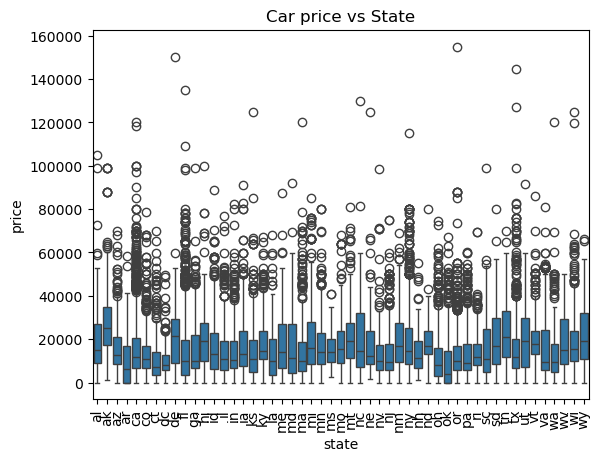

In [67]:
# Price vs State
sns.boxplot(x='state', y='price', data=df)
plt.title('Car price vs State')
plt.xticks(rotation=90)
plt.show()

# **Data Preparation**

In [68]:
# Create a new age folumn from the year column
df['age'] = 2025 - df['year']

df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,age
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al,7.0
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al,6.0
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al,7.0
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al,23.0
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al,30.0


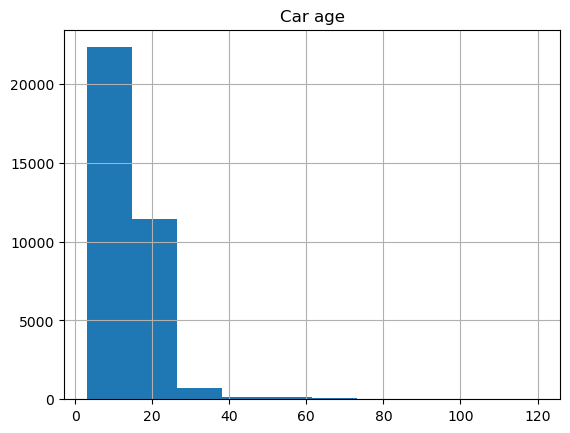

In [69]:
df['age'].hist()
plt.title('Car age')
plt.show()

In [70]:
df['price'].corr(df['age'])

-0.25405858410837534

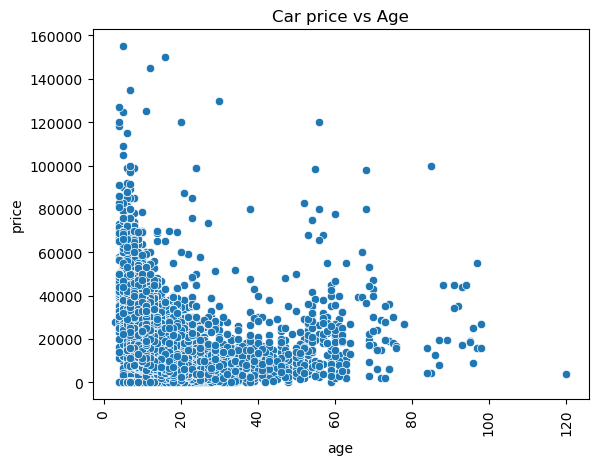

In [71]:
# Price vs Age
sns.scatterplot(x='age', y='price', data=df)
plt.title('Car price vs Age')
plt.xticks(rotation=90)
plt.show()

In [72]:
# Split the data into X_train, X_test, y_train and y_test
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
X_train.head()

,id,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,age
228392,7302572049,kalispell,2005.0,ram,1500 quad cab,excellent,8 cylinders,gas,77000.0,clean,automatic,1D7HU18P05J620269,4wd,full-size,pickup,grey,mt,20.0
68962,7302790197,ventura county,1999.0,gmc,yukon slt,excellent,8 cylinders,gas,195000.0,clean,automatic,1GKEC13R9XJ722833,rwd,mid-size,SUV,custom,ca,26.0
361235,7310851607,nashville,2014.0,ford,f350,excellent,8 cylinders,gas,198850.0,clean,automatic,1FDRF3G6XEEA55594,rwd,full-size,truck,white,tn,11.0
218431,7303480311,hattiesburg,2005.0,toyota,4runner,good,8 cylinders,gas,236000.0,clean,automatic,JTEBT14R950050588,4wd,full-size,SUV,grey,ms,20.0
390446,7315416493,fredericksburg,2013.0,mercedes-benz,benz s550,excellent,8 cylinders,gas,79712.0,clean,automatic,WDDNG9EBXDA531244,4wd,mid-size,sedan,white,va,12.0


In [74]:
X_test.head()

,id,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,age
421994,7302010346,madison,2014.0,ford,transit connect,good,4 cylinders,gas,143546.0,clean,automatic,NM0LS7F75E1164637,fwd,full-size,van,red,wi,11.0
359017,7316155054,nashville,2017.0,kia,soul plus,like new,4 cylinders,gas,63496.0,clean,automatic,KNDJP3A51H7457654,fwd,mid-size,mini-van,blue,tn,8.0
119389,7316241495,treasure coast,2010.0,chevrolet,silverado 1500 ltz 4x4,excellent,8 cylinders,gas,124248.0,clean,automatic,3GCRKTE37AG118369,4wd,full-size,pickup,red,fl,15.0
4642,7309388743,montgomery,2015.0,volkswagen,passat tsi wolfsburg,excellent,4 cylinders,gas,100274.0,clean,automatic,1VWAT7A31FC018187,fwd,mid-size,sedan,white,al,10.0
381660,7313268847,san antonio,2011.0,mazda,3,good,4 cylinders,gas,77312.0,clean,manual,JM1BL1U59B1435270,fwd,mid-size,sedan,grey,tx,14.0


In [75]:
# Drop id and VIN from X_train and X_test
X_train = X_train.drop(columns=['id', 'VIN'])
X_test = X_test.drop(columns=['id', 'VIN'])

In [76]:
# Create a ColumnTransformer to apply different transformations to different column types
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns
numerical_features = X_train.select_dtypes(include=np.number).columns

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

In [77]:
# Create a pipepline that does the following: 1) Uses onehotencoder to encode categorical variables in df, scales numerical variables, then performs Linear regression .
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [78]:
# Use GridSearch to build a model with the above pipeline, pipe
param_grid = {
    'model__fit_intercept': [True, False]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'model__fit_intercept': False}
Best cross-validation score: -0.3026906262373076


In [79]:
# show best model and its coefficients
print(grid.best_estimator_)
print(grid.best_estimator_.named_steps['model'].coef_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['year', 'odometer', 'age'], dtype='object'))])),
                ('model', LinearRegression(fit_intercept=False))])
[ 3694.84484806 -3113.43091381  -567.47727721 ...  2281.57732281
 -3614.360712   -2281.57730836]


In [80]:
# Show the most important features from the model
importances = grid.best_estimator_.named_steps['model'].coef_

# Get the feature names after transformation
transformed_feature_names = grid.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# Create the Series with the transformed feature names as the index
important_features = pd.Series(importances, index=transformed_feature_names)
lst = important_features.sort_values(ascending=False)
print(lst)

onehot__manufacturer_buick              348712.782649
onehot__model_benz sprinter             122853.555401
onehot__model_f150 longbed              117984.350485
onehot__model_challenger srt demon      111676.441420
onehot__model_corvette lt3               93036.259048
                                            ...      
onehot__model_lacrosse premium         -367219.904137
onehot__model_lacrosse cxl 4dr sedan   -368257.529876
onehot__model_encore leather           -368337.614924
onehot__model_encore gx                -369726.715872
onehot__model_encore leather sport     -370516.814988
Length: 5143, dtype: float64


In [81]:
lst.head(25)

onehot__manufacturer_buick            348712.782649
onehot__model_benz sprinter           122853.555401
onehot__model_f150 longbed            117984.350485
onehot__model_challenger srt demon    111676.441420
onehot__model_corvette lt3             93036.259048
onehot__model_850i                     84715.631791
onehot__model_astro cargo              82309.884167
onehot__model_210                      78309.715839
onehot__model_galaxie                  78172.576893
onehot__model_911 turbo s              76869.471489
onehot__model_sedan                    74257.885611
onehot__model_chevelle ss              73052.863338
onehot__model_2 door                   72797.300027
onehot__model_k10                      71305.649864
onehot__model_star chief               70107.199583
onehot__model_hot rod                  65817.713853
onehot__model_vicky                    65256.556532
onehot__model_wagon                    64679.809414
onehot__model_454 ss                   61544.352448
onehot__mode

In [82]:
lst.tail(25)

onehot__model_rendezvous                -363685.968594
onehot__model_enclave awd 4dr leather   -364131.216343
onehot__model_encore                    -364138.280051
onehot__model_encore preferred ii fwd   -364202.237891
onehot__model_encore preferred fwd      -364423.132410
onehot__model_lucerne cx                -364608.341720
onehot__model_lucerne cxl v6 - gold     -364709.952217
onehot__model_verano                    -365079.200436
onehot__model_lacrosse leather          -365189.171607
onehot__model_riviera supercharged      -365226.029388
onehot__model_regal t                   -365298.559270
onehot__model_encore leather awd        -365309.431727
onehot__model_lucerne cxl               -365396.738928
onehot__model_regal                     -365620.153624
onehot__model_encore sport utility 4d   -365929.269993
onehot__model_encore convenience        -366270.220476
onehot__model_regal premium             -366344.930083
onehot__model_encore essence, awd       -366919.833221
onehot__mo

In [83]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

              Importance
model          16.688599
manufacturer   15.866556
region          0.085959
state           0.058833
odometer        0.052359
fuel            0.035105
type            0.020021
size            0.014639
transmission    0.011141
year            0.008379
age             0.008379
drive           0.005848
title_status    0.004468
cylinders       0.004383
paint_color     0.002811
condition       0.002735
